# Featurization, Model Selection & Tuning - Linear Regression

**Why is regularization required ?**

We are well aware of the issue of 'Curse of dimensionality', where the no. of columns are so huge that the no. of rows does not cover all the permutation and combinations that is applicable for this dataset.
For eg: Data having 10 columns should have 10! rows but it has only 1000 rows

Therefore,when we depict this graphically there would be lot of white spaces as the datapoints for those regions may not be covered in the dataset.

If a  linear regression model is tested over such a data, the model will tend to overfit this data by having sharp peaks & slopes. Such a model would have 100% training accuracy but would definitely fail in the test environment.

Thus arose the need of introducing slight errors in the form of giving smooth bends instead of sharp peaks (thereby reducing overfit).This is achieved by tweaking the model parameters (coefficients) and the hyperparameters (penalty factor). 

## Agenda

* Perform basic EDA
* Scale data and apply Linear, Ridge & Lasso Regression with Regularization 
* Compare the r^2 score to determine which of the above regression methods gives the highest score
* Compute Root mean squared error (RMSE) which inturn gives a better score than r^2
* Finally use a scatter plot to graphically depict the correlation between actual and predicted mpg values

# 1. Import packages and observe dataset

In [1]:
#Import numerical libraries
import pandas as pd
import numpy as np

#Import graphical plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#Import Linear Regression Machine Learning Libraries
from sklearn import preprocessing
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score

In [2]:
data = pd.read_csv(r'C:\Users\sai.venkat\OneDrive\DataScience\Python\PYTHON_BIGINNER\Libraries\Machine Learning\Feature Selection Technique\lasso, ridge, elastic net\TASK-22_LASSO,RIDGE\car-mpg.csv')
data.head()

,mpg,cyl,disp,hp,wt,acc,yr,origin,car_type,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,0,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,0,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,0,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,0,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,0,ford torino


In [3]:
#Drop car name
#Replace origin into 1,2,3.. dont forget get_dummies
#Replace ? with nan
#Replace all nan with median
data['origin'] = data['origin'].replace({1: 'america', 2: 'europe', 3: 'asia'})
data = pd.get_dummies(data,columns = ['origin'])
data = data.replace('?', np.nan)
data = data.drop(['car_name'], axis = 1)
data[['origin_america', 'origin_asia', 'origin_europe']] = data[['origin_america', 'origin_asia', 'origin_europe']].astype(int)
data

#data = data.apply(lambda x: x.fillna(x.median()), axis = 0)
#data[data.select_dtypes(include=np.number).columns] = data.select_dtypes(include=np.number).apply(lambda x: x.fillna(x.median()), axis=0)
#data

,mpg,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe
0,18.0,8,307.0,130,3504,12.0,70,0,1,0,0
1,15.0,8,350.0,165,3693,11.5,70,0,1,0,0
2,18.0,8,318.0,150,3436,11.0,70,0,1,0,0
3,16.0,8,304.0,150,3433,12.0,70,0,1,0,0
4,17.0,8,302.0,140,3449,10.5,70,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,1,0,0
394,44.0,4,97.0,52,2130,24.6,82,1,0,0,1
395,32.0,4,135.0,84,2295,11.6,82,1,1,0,0
396,28.0,4,120.0,79,2625,18.6,82,1,1,0,0


In [5]:
data.describe()
data.info()
data.replace('?', np.nan, inplace=True)
data['hp'].replace('?', np.nan, inplace=True)
data['hp'] = pd.to_numeric(data['hp'], errors='coerce')
data['hp'].fillna(0, inplace=True)  # Replace NaNs if needed
data['hp'] = data['hp'].astype(int)
data.isnull().sum()
data = data.apply(lambda x: x.fillna(x.median()), axis = 0)
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mpg             398 non-null    float64
 1   cyl             398 non-null    int64  
 2   disp            398 non-null    float64
 3   hp              398 non-null    int32  
 4   wt              398 non-null    int64  
 5   acc             398 non-null    float64
 6   yr              398 non-null    int64  
 7   car_type        398 non-null    int64  
 8   origin_america  398 non-null    int32  
 9   origin_asia     398 non-null    int32  
 10  origin_europe   398 non-null    int32  
dtypes: float64(3), int32(4), int64(4)
memory usage: 28.1 KB


C:\Users\sai.venkat\AppData\Local\Temp\ipykernel_20788\4051688727.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['hp'].replace('?', np.nan, inplace=True)
C:\Users\sai.venkat\AppData\Local\Temp\ipykernel_20788\4051688727.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



,mpg,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe
0,18.0,8,307.0,130,3504,12.0,70,0,1,0,0
1,15.0,8,350.0,165,3693,11.5,70,0,1,0,0
2,18.0,8,318.0,150,3436,11.0,70,0,1,0,0
3,16.0,8,304.0,150,3433,12.0,70,0,1,0,0
4,17.0,8,302.0,140,3449,10.5,70,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,1,0,0
394,44.0,4,97.0,52,2130,24.6,82,1,0,0,1
395,32.0,4,135.0,84,2295,11.6,82,1,1,0,0
396,28.0,4,120.0,79,2625,18.6,82,1,1,0,0


In [6]:
data

,mpg,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe
0,18.0,8,307.0,130,3504,12.0,70,0,1,0,0
1,15.0,8,350.0,165,3693,11.5,70,0,1,0,0
2,18.0,8,318.0,150,3436,11.0,70,0,1,0,0
3,16.0,8,304.0,150,3433,12.0,70,0,1,0,0
4,17.0,8,302.0,140,3449,10.5,70,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,1,0,0
394,44.0,4,97.0,52,2130,24.6,82,1,0,0,1
395,32.0,4,135.0,84,2295,11.6,82,1,1,0,0
396,28.0,4,120.0,79,2625,18.6,82,1,1,0,0


In [66]:
data.head()

,mpg,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe
0,18.0,8,307.0,130,3504,12.0,70,0,1,0,0
1,15.0,8,350.0,165,3693,11.5,70,0,1,0,0
2,18.0,8,318.0,150,3436,11.0,70,0,1,0,0
3,16.0,8,304.0,150,3433,12.0,70,0,1,0,0
4,17.0,8,302.0,140,3449,10.5,70,0,1,0,0


We have to predict the mpg column given the features.

# 2. Model building

Here we would like to scale the data as the columns are varied which would result in 1 column dominating the others.

First we divide the data into independent (X) and dependent data (y) then we scale it. 

#### Tip!: ####

*The reason we don't scale the entire data before and then divide it into train(X) & test(y) is because once you scale the data, the type(data_s) would be numpy.ndarray. It's impossible to divide this data when it's an array. 
*

Hence we divide type(data) pandas.DataFrame, then proceed to scaling it.

In [7]:
X = data.drop(['mpg'], axis = 1) # independent variable
y = data[['mpg']] #dependent variable

In [8]:
#Scaling the data

X_s = preprocessing.scale(X)
X_s = pd.DataFrame(X_s, columns = X.columns) #converting scaled data into dataframe

y_s = preprocessing.scale(y)
y_s = pd.DataFrame(y_s, columns = y.columns) #ideally train, test data should be in columns

In [9]:
#Split into train, test set

X_train, X_test, y_train,y_test = train_test_split(X_s, y_s, test_size = 0.30, random_state = 1)
X_train.shape

(278, 10)

## 2.a Simple Linear Model

In [10]:
#Fit simple linear model and find coefficients
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

for idx, col_name in enumerate(X_train.columns):
    print('The coefficient for {} is {}'.format(col_name, regression_model.coef_[0][idx]))
    
intercept = regression_model.intercept_[0]
print('The intercept is {}'.format(intercept))

The coefficient for cyl is 0.2926084066436733
The coefficient for disp is 0.31030529029403214
The coefficient for hp is -0.1281033654496636
The coefficient for wt is -0.7703999427201306
The coefficient for acc is 0.04439369483182379
The coefficient for yr is 0.38239501638901635
The coefficient for car_type is 0.35411949830516604
The coefficient for origin_america is -0.07455908701765933
The coefficient for origin_asia is 0.043516011892083276
The coefficient for origin_europe is 0.049187723642028315
The intercept is 0.018222326070649997


## 2.b Regularized Ridge Regression

In [11]:
#alpha factor here is lambda (penalty term) which helps to reduce the magnitude of coeff

ridge_model = Ridge(alpha = 0.3)
ridge_model.fit(X_train, y_train)

print('Ridge model coef: {}'.format(ridge_model.coef_))
#As the data has 10 columns hence 10 coefficients appear here    

Ridge model coef: [[ 0.28893377  0.2981552  -0.1288491  -0.75919375  0.04224725  0.38117233
   0.35051759 -0.07409233  0.04346943  0.04864319]]


## 2.c Regularized Lasso Regression

In [12]:
#alpha factor here is lambda (penalty term) which helps to reduce the magnitude of coeff

lasso_model = Lasso(alpha = 0.1)
lasso_model.fit(X_train, y_train)

print('Lasso model coef: {}'.format(lasso_model.coef_))
#As the data has 10 columns hence 10 coefficients appear here   

Lasso model coef: [-0.         -0.         -0.         -0.53352631  0.          0.28360834
  0.12764287 -0.01532777  0.          0.        ]


Here we notice many coefficients are turned to 0 indicating drop of those dimensions from the model

# 3. Score Comparison

In [13]:
#Model score - r^2 or coeff of determinant
#r^2 = 1-(RSS/TSS) = Regression error/TSS 


#Simple Linear Model
print(regression_model.score(X_train, y_train))
print(regression_model.score(X_test, y_test))

print('*************************')
#Ridge
print(ridge_model.score(X_train, y_train))
print(ridge_model.score(X_test, y_test))

print('*************************')
#Lasso
print(lasso_model.score(X_train, y_train))
print(lasso_model.score(X_test, y_test))

0.8315881244193795
0.8569388729714708
*************************
0.8315722323492428
0.857539962739915
*************************
0.7934736427697255
0.837266472923356


## Polynomial Features

If you wish to further compute polynomial features, you can use the below code.

In [12]:
#poly = PolynomialFeatures(degree = 2, interaction_only = True)

#Fit calculates u and std dev while transform applies the transformation to a particular set of examples
#Here fit_transform helps to fit and transform the X_s
#Hence type(X_poly) is numpy.array while type(X_s) is pandas.DataFrame 
#X_poly = poly.fit_transform(X_s)
#Similarly capture the coefficients and intercepts of this polynomial feature model

# 4. Model Parameter Tuning

* r^2 is not a reliable metric as it always increases with addition of more attributes even if the attributes have no influence on the predicted variable. Instead we use adjusted r^2 which removes the statistical chance that improves r^2 

(adjusted r^2 = r^2 - fluke)
* Scikit does not provide a facility for adjusted r^2... so we use statsmodel, a library that gives results similar to what you obtain in R language
* This library expects the X and Y to be given in one single dataframe

In [14]:
data_train_test = pd.concat([X_train, y_train], axis =1)
data_train_test.head()

,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe,mpg
350,-0.856321,-0.849116,-0.991933,-0.893172,-0.242570,1.351199,0.941412,0.773559,-0.497643,-0.461968,1.432898
59,-0.856321,-0.925936,-1.215708,-0.847061,2.879909,-1.085858,0.941412,-1.292726,-0.497643,2.164651,-0.065919
120,-0.856321,-0.695475,0.226399,-0.121101,-0.024722,-0.815074,0.941412,-1.292726,-0.497643,2.164651,-0.578335
12,1.498191,1.983643,1.171228,0.934732,-2.203196,-1.627426,-1.062235,0.773559,-0.497643,-0.461968,-1.090751
349,-0.856321,-0.983552,-0.867613,-1.165111,0.156817,1.351199,0.941412,-1.292726,2.009471,-0.461968,1.356035


In [15]:
import statsmodels.formula.api as smf
ols1 = smf.ols(formula = 'mpg ~ cyl+disp+hp+wt+acc+yr+car_type+origin_america+origin_europe+origin_asia', data = data_train_test).fit()
ols1.params

Intercept         0.018222
cyl               0.292608
disp              0.310305
hp               -0.128103
wt               -0.770400
acc               0.044394
yr                0.382395
car_type          0.354119
origin_america   -0.074559
origin_europe     0.049188
origin_asia       0.043516
dtype: float64

In [16]:
print(ols1.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     147.0
Date:                Fri, 28 Mar 2025   Prob (F-statistic):           2.89e-98
Time:                        19:14:48   Log-Likelihood:                -149.21
No. Observations:                 278   AIC:                             318.4
Df Residuals:                     268   BIC:                             354.7
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0182      0.025      0.

In [17]:
#Lets check Sum of Squared Errors (SSE) by predicting value of y for test cases and subtracting from the actual y for the test cases
mse  = np.mean((regression_model.predict(X_test)-y_test)**2)

# root of mean_sq_error is standard deviation i.e. avg variance between predicted and actual
import math
rmse = math.sqrt(mse)
print('Root Mean Squared Error: {}'.format(rmse))

Root Mean Squared Error: 0.37049181097916517


**So there is an avg. mpg difference of 0.37 from real mpg**

<Axes: xlabel='acc', ylabel='mpg'>

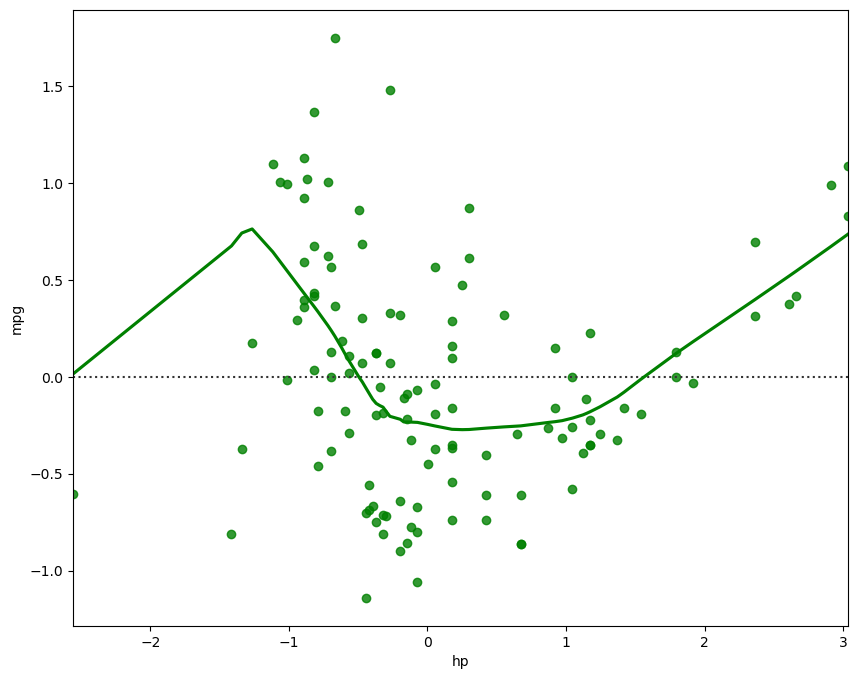

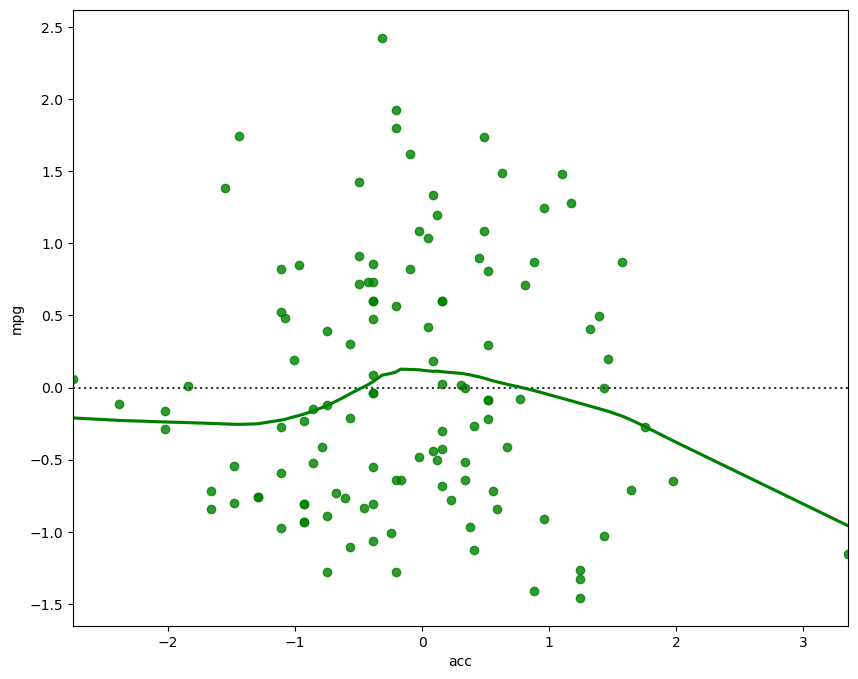

In [18]:
# Is OLS a good model ? Lets check the residuals for some of these predictor.

fig = plt.figure(figsize=(10,8))
sns.residplot(x= X_test['hp'], y= y_test['mpg'], color='green', lowess=True )


fig = plt.figure(figsize=(10,8))
sns.residplot(x= X_test['acc'], y= y_test['mpg'], color='green', lowess=True )

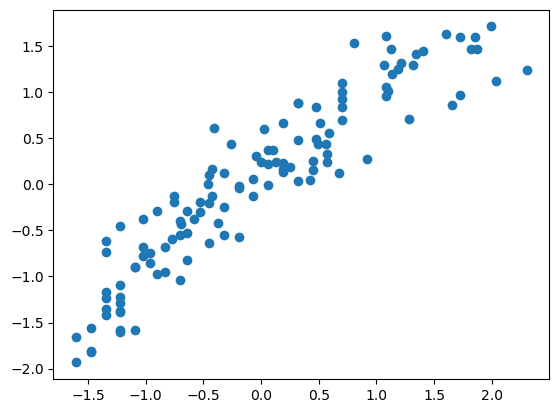

In [19]:
# predict mileage (mpg) for a set of attributes not in the training or test set
y_pred = regression_model.predict(X_test)

# Since this is regression, plot the predicted y value vs actual y values for the test data
# A good model's prediction will be close to actual leading to high R and R2 values
#plt.rcParams['figure.dpi'] = 500
plt.scatter(y_test['mpg'], y_pred)

# 5. Inference

**Both Ridge & Lasso regularization performs very well on this data, though Ridge gives a better score. The above scatter plot depicts the correlation between the actual and predicted mpg values.**

***This kernel is a work in progress.***